## EDA and modeling

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
pcos_df = pd.read_csv('../data/cleaned/cleaned_PCOS_infertility.csv')
pcos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             541 non-null    int64  
 1   Patient File No.       541 non-null    float64
 2   PCOS (Y/N)             541 non-null    float64
 3    Age (yrs)             541 non-null    float64
 4   Weight (Kg)            541 non-null    float64
 5   Height(Cm)             541 non-null    float64
 6   BMI                    541 non-null    float64
 7   Blood Group            541 non-null    float64
 8   Pulse rate(bpm)        541 non-null    float64
 9   RR (breaths/min)       541 non-null    float64
 10  Hb(g/dl)               541 non-null    float64
 11  Cycle(R/I)             541 non-null    float64
 12  Cycle length(days)     541 non-null    float64
 13  Marraige Status (Yrs)  541 non-null    float64
 14  Pregnant(Y/N)          541 non-null    float64
 15  No. of

In [94]:
pcos_df.shape

(541, 43)

In [37]:
pcos_df.columns = pcos_df.columns.str.strip()
pcos_df.columns

Index(['Patient File No.', 'PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)',
       'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)',
       'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)',
       'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions',
       'Beta_HCG_I(mIU/mL)', 'Beta_HCG_II(mIU/mL)', 'FSH(mIU/mL)',
       'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio',
       'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)',
       'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object')

In [31]:
pcos_df.drop('Unnamed: 0', axis=1, inplace=True)
pcos_df

,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1.0,0.0,28.0,44.6,152.000,19.300000,15.0,78.0,22.0,10.48,...,0.0,1.0,0.0,110.0,80.0,3.0,3.0,18.0,18.0,8.5
1,2.0,0.0,36.0,65.0,161.500,24.921163,15.0,74.0,20.0,11.70,...,0.0,0.0,0.0,120.0,70.0,3.0,5.0,15.0,14.0,3.7
2,3.0,1.0,33.0,68.8,165.000,25.270891,11.0,72.0,18.0,11.80,...,1.0,1.0,0.0,120.0,80.0,13.0,15.0,18.0,20.0,10.0
3,4.0,0.0,37.0,65.0,148.000,29.674945,13.0,72.0,20.0,12.00,...,0.0,0.0,0.0,120.0,70.0,2.0,2.0,15.0,14.0,7.5
4,5.0,0.0,25.0,52.0,161.000,20.060954,11.0,72.0,18.0,10.00,...,0.0,0.0,0.0,120.0,80.0,3.0,4.0,16.0,14.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,537.0,0.0,35.0,50.0,164.592,18.500000,17.0,72.0,16.0,11.00,...,0.0,0.0,0.0,110.0,70.0,1.0,0.0,17.5,10.0,6.7
537,538.0,0.0,30.0,63.2,158.000,25.300000,15.0,72.0,18.0,10.80,...,0.0,0.0,0.0,110.0,70.0,9.0,7.0,19.0,18.0,8.2
538,539.0,0.0,36.0,54.0,152.000,23.400000,13.0,74.0,20.0,10.80,...,0.0,0.0,0.0,110.0,80.0,1.0,0.0,18.0,9.0,7.3
539,540.0,0.0,27.0,50.0,150.000,22.200000,15.0,74.0,20.0,12.00,...,1.0,0.0,0.0,110.0,70.0,7.0,6.0,18.0,16.0,11.5


<Axes: >

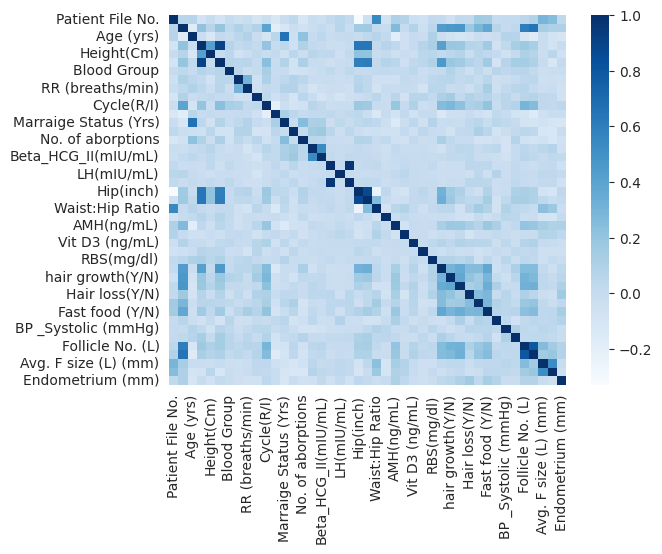

In [32]:
# not so useful
corr = pcos_df.corr()
sns.heatmap(corr, cmap="Blues")

In [90]:
# check each column to see the amount of correlation each column has with 'PCOS (Y/N)'
corr = pcos_df.corr()['PCOS (Y/N)'].sort_values(ascending=False)
corr

PCOS (Y/N)               1.000000
Follicle No. (R)         0.648327
Follicle No. (L)         0.603346
Skin darkening (Y/N)     0.475733
hair growth(Y/N)         0.464667
Weight gain(Y/N)         0.441047
Cycle(R/I)               0.401644
Fast food (Y/N)          0.376183
Pimples(Y/N)             0.286077
AMH(ng/mL)               0.264141
Weight (Kg)              0.211938
BMI                      0.199534
Hair loss(Y/N)           0.172879
Waist(inch)              0.164598
Hip(inch)                0.162297
Avg. F size (L) (mm)     0.132992
Endometrium (mm)         0.106648
Avg. F size (R) (mm)     0.097690
Pulse rate(bpm)          0.091821
Hb(g/dl)                 0.087170
Vit D3 (ng/mL)           0.085494
Height(Cm)               0.068254
Reg.Exercise(Y/N)        0.065337
LH(mIU/mL)               0.063879
Patient File No.         0.060998
RBS(mg/dl)               0.048922
BP _Diastolic (mmHg)     0.038032
RR (breaths/min)         0.036928
Blood Group              0.036433
Beta_HCG_II(mI

<Axes: >

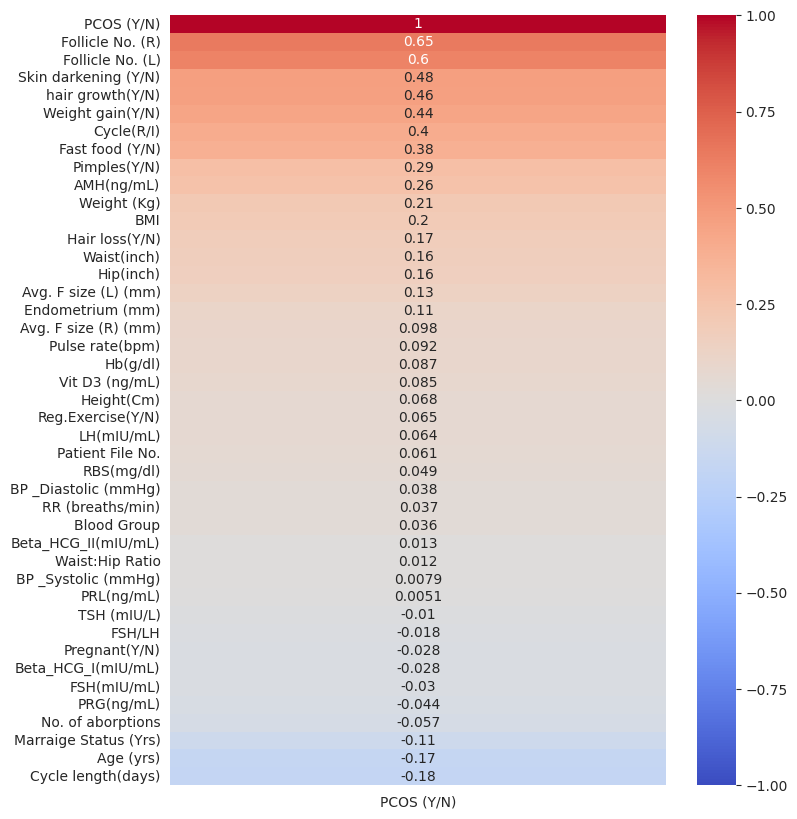

In [92]:
# plot the relation between each column and 'PCOS (Y/N)'
plt.figure(figsize=(8,10))
sns.heatmap(pcos_df.corr()[['PCOS (Y/N)']].sort_values(by='PCOS (Y/N)', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [34]:
pcos_df['PCOS (Y/N)'].value_counts()

PCOS (Y/N)
0.0    364
1.0    177
Name: count, dtype: int64

Text(0.5, 1.0, 'PCOS Distribution')

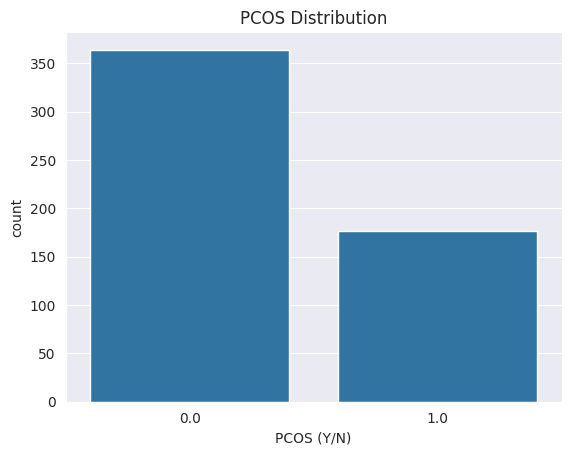

In [35]:
sns.countplot(pcos_df, x='PCOS (Y/N)')
plt.title('PCOS Distribution')

![image.png](attachment:9e0bd72f-62a9-4c9e-a51f-34883a6806e3.png)

#### A boxplot is designed to show the distribution of a continuous (numeric) variable across categories.
not suitable for when both columns have binary values

<Axes: xlabel='PCOS (Y/N)', ylabel='BMI'>

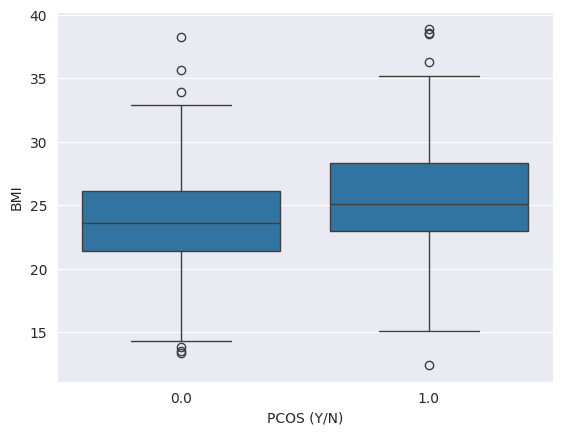

In [60]:
sns.boxplot(data=pcos_df, x='PCOS (Y/N)', y='BMI')

<Axes: xlabel='PCOS (Y/N)', ylabel='Follicle No. (L)'>

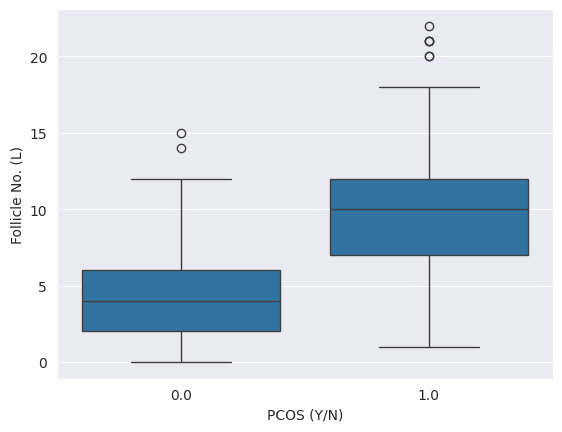

In [44]:
sns.boxplot(pcos_df, x='PCOS (Y/N)', y='Follicle No. (L)')

<Axes: xlabel='PCOS (Y/N)', ylabel='Follicle No. (R)'>

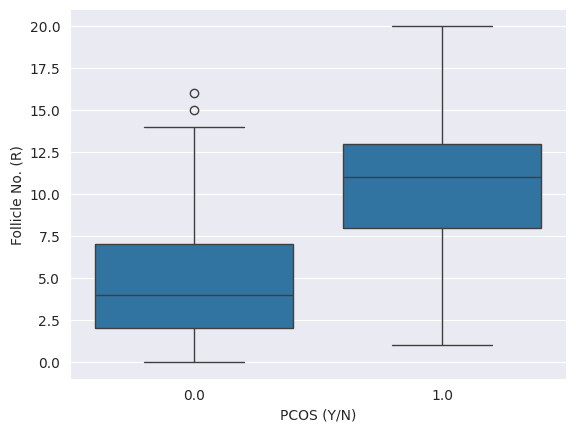

In [43]:
sns.boxplot(pcos_df, x='PCOS (Y/N)', y='Follicle No. (R)')

<Axes: xlabel='PCOS (Y/N)', ylabel='Marraige Status (Yrs)'>

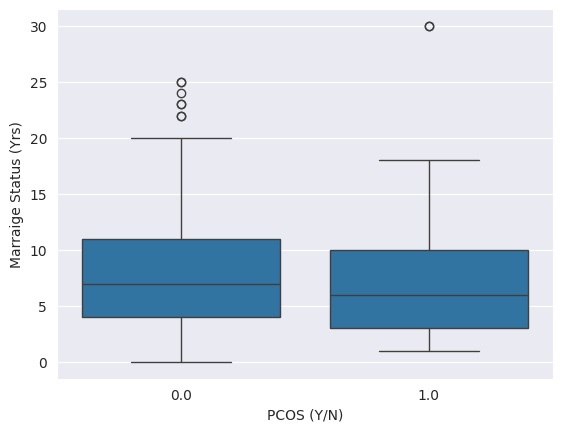

In [52]:
sns.boxplot(pcos_df, x='PCOS (Y/N)', y='Marraige Status (Yrs)')

<Axes: xlabel='Marraige Status (Yrs)', ylabel='Count'>

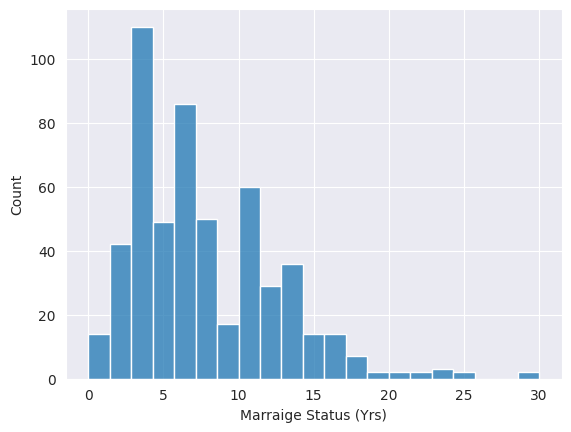

In [53]:
sns.histplot(pcos_df['Marraige Status (Yrs)'])

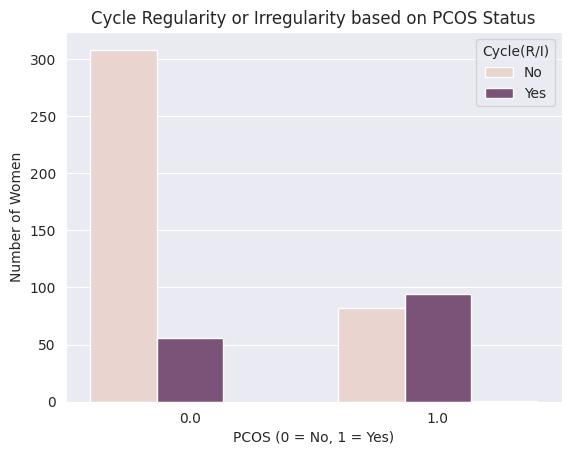

In [65]:
sns.countplot(pcos_df, x='PCOS (Y/N)', hue='Cycle(R/I)')
plt.title('Cycle Regularity or Irregularity based on PCOS Status')
plt.xlabel('PCOS (0 = No, 1 = Yes)')
plt.ylabel('Number of Women')
plt.legend(title='Cycle(R/I)', labels=['No', 'Yes'])

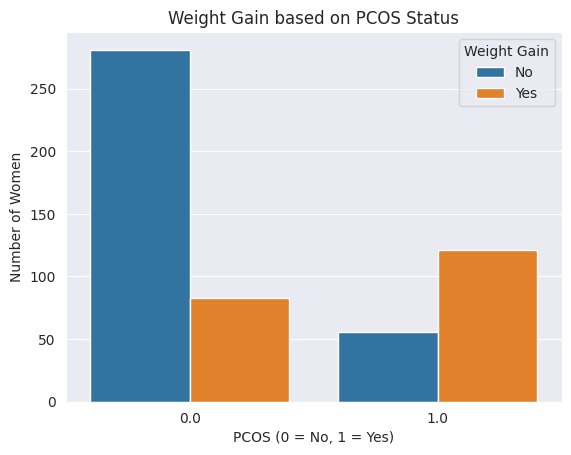

In [71]:
sns.countplot(pcos_df, x='PCOS (Y/N)', hue='Weight gain(Y/N)')
plt.title('Weight Gain based on PCOS Status')
plt.xlabel('PCOS (0 = No, 1 = Yes)')
plt.ylabel('Number of Women')
plt.legend(title='Weight Gain', labels=['No', 'Yes'])

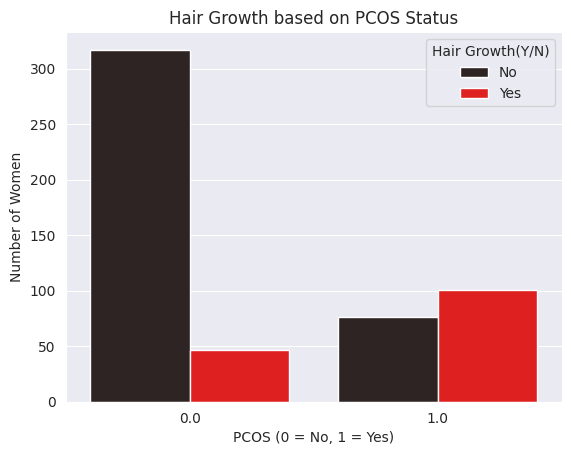

In [84]:
sns.countplot(pcos_df, x='PCOS (Y/N)', hue='hair growth(Y/N)', palette='dark:red')
plt.title('Hair Growth based on PCOS Status')
plt.xlabel('PCOS (0 = No, 1 = Yes)')
plt.ylabel('Number of Women')
plt.legend(title='Hair Growth(Y/N)', labels=['No', 'Yes'])

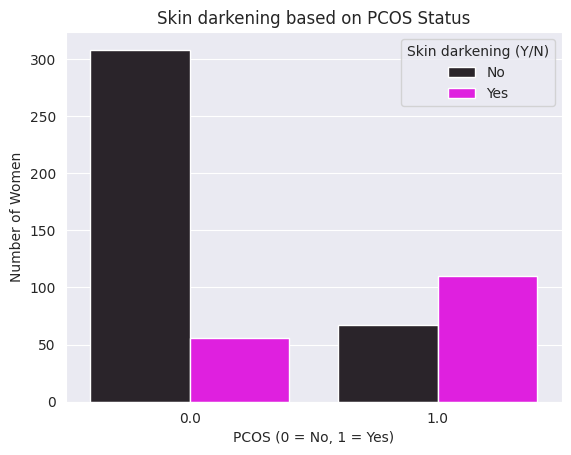

In [81]:
sns.countplot(pcos_df, x='PCOS (Y/N)', hue='Skin darkening (Y/N)', palette='dark:magenta')
plt.title('Skin darkening based on PCOS Status')
plt.xlabel('PCOS (0 = No, 1 = Yes)')
plt.ylabel('Number of Women')
plt.legend(title='Skin darkening (Y/N)', labels=['No', 'Yes'])